# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [15]:
import sys, os, openpyxl as _xl
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
from optimizer import run_optimization
print('Setup OK')

Setup OK


## 1. Model and technologies

In [16]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

Model CleanStep exists with the correct technologies.


## 2. Country-level inputs

In [17]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [18]:
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 3101.6, 2235.1, 2355.9, 2518.5, 1659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


### Capital Structure Optimisation
Optuna searches for the combination of equity/grants/debt/costs that minimises total debt (or long-term subsidies) across the planning horizon. `SEARCH_RANGES` defines the search space and `OBJECTIVE` controls what is minimised.

In [19]:
SEARCH_RANGES = {
    'pct_equity':          (0.10, 0.50),
    'pct_grants':          (0.10, 0.60), #60
    'cost_equity':         (0.08, 0.20),
    'cost_debt':           (0.04, 0.12),
    'years_realisation':   (4, 10),
    'grace_period':        (1, 6),
    'amortization_period': (5, 30),
}
OBJECTIVE = 'debt'   # 'debt'/'lts
N_TRIALS  = 100

CAPITAL_STRUCTURE = {}
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"Optimising {tech}...")
    CAPITAL_STRUCTURE[tech] = run_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        fuel_fin=FUEL_FIN,
        fuel_key='Electricity',
        search_ranges=SEARCH_RANGES,
        objective=OBJECTIVE,
        n_trials=N_TRIALS,
    )
    print(f"  → {CAPITAL_STRUCTURE[tech]}")

print("Optimising LPG...")
CAPITAL_STRUCTURE['LPG'] = run_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    fuel_fin=FUEL_FIN,
    fuel_key='LPG',
    search_ranges=SEARCH_RANGES,
    objective=OBJECTIVE,
    n_trials=N_TRIALS,
)
print(f"  → {CAPITAL_STRUCTURE['LPG']}")

for sheet, cs in CAPITAL_STRUCTURE.items():
    print(f"\n{sheet}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  CAPEX  " + "".join(f"{round(v,1):>10}" for v in cs.get('CAPEX_SCHEDULE', [])))
    print("  DEBT   " + "".join(f"{round(v,1):>10}" for v in cs.get('DEBT_INCREASE',  [])))
    print("  LTS    " + "".join(f"{round(v,1):>10}" for v in cs.get('LT_SUBSIDY_SCHEDULE', [])))

Optimising Electricity & E-Cooking...
K1=0.14, K2=0.48
Trial 0: total debt=2e+02, debt=[0, 164.46158780977433, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[0, 403.95325224793237, 170.4568848978423, 183.2318910633923, 231.96062541910345, 297.84943880399203, 382.7597388149654, 491.76744370796865, 631.6636266002049, 811.1908221717738, 452.82421348189246, 473.3420627909336], lt_subsidies=[0, 266.7777758252639, 132.93644885186094, 150.27985187001624, 191.15624917276716, 245.54736492362372, 315.55415867754846, 405.4197470904989, 520.7486534667377, 668.7487209414065, 600.1747867308545, 638.4248602994907]
Trial 1: total debt=7e+02, debt=[0, 653.084142213622, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[0, 1007.1997492352826, 267.2541275989375, 245.5398641199469, 280.4104454176777, 325.0173104405374, 376.86298218678286, 436.77535965598946, 350.44266438672594, 377.21147473337504, 412.6858622688417, 451.6001599559042], lt_subsidies=[0, 570.6723275012002, 262.52306758193595, 259.60735236624674, 298.145287836926

## 4. Write inputs

In [20]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.carbon_credits_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  carbon-credits.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  carbon-credits.xlsx / Carbon Credits -> Liquidity
  carbon-credits.xlsx / Carbon Credits -> Price per TON
  carbon-credits.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 41
  design-capital-CleanStep.xlsx / Electricity & E

## 5. Run engine

In [21]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
print('Done.')

Running engine...
  Converged in 14 iterations.
Done.


In [22]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,668.845190,274.226528,401.307114,12.251222,16.743410,612.067869,293.792577,361.120043,7.25102,...,1043.719268,286.124391,1172.205391,47.225568,4.225568,1950.501740,7172.617849,3702.887229,320.187229,NaN
1,2,668.845190,274.226528,401.307114,12.251222,16.743410,612.067869,293.792577,361.120043,7.25102,...,544.614465,286.124391,1172.205391,57.597067,14.597067,1949.592846,7171.864728,4334.787201,952.087201,1171.788513
2,3,754.382348,309.296763,452.629409,12.251222,16.771395,503.734895,241.792749,297.203588,7.25102,...,544.667524,285.407891,1171.488891,57.597067,14.597067,1943.317144,7165.316282,4334.631428,951.931428,108.332974
3,4,754.329289,309.275008,452.597573,12.251222,16.771380,503.890668,241.867520,297.295494,7.25102,...,551.376558,285.407891,1171.488891,56.880567,13.880567,1943.555862,7165.555474,4328.153956,945.453956,13.231994
4,5,753.235741,308.826654,451.941445,12.251222,16.771061,505.001166,242.400560,297.950688,7.25102,...,551.372850,285.463480,1171.544480,56.880567,13.880567,1943.889063,7165.892045,4328.165211,945.465211,1.110498
5,6,753.236345,308.826902,451.941807,12.251222,16.771061,504.999236,242.399633,297.949549,7.25102,...,551.296317,285.463480,1171.544480,56.936156,13.936156,1944.167774,7166.170750,4328.245255,945.545255,0.650516
6,7,753.248820,308.832016,451.949292,12.251222,16.771065,504.985514,242.393047,297.941453,7.25102,...,551.296359,285.459234,1171.540234,56.936156,13.936156,1944.471330,7166.474265,4328.245116,945.545116,0.487388
7,8,753.248813,308.832013,451.949288,12.251222,16.771065,504.985537,242.393058,297.941467,7.25102,...,551.297233,285.459234,1171.540234,56.931910,13.931910,1944.806254,7166.809189,4328.244129,945.544129,0.485620
8,9,753.248671,308.831955,451.949202,12.251222,16.771065,504.985707,242.393139,297.941567,7.25102,...,551.297233,285.459559,1171.540559,56.931910,13.931910,1945.176253,7167.179188,4328.244131,945.544131,0.498729
9,10,753.248671,308.831955,451.949203,12.251222,16.771065,504.985706,242.393139,297.941567,7.25102,...,551.297223,285.459559,1171.540559,56.932235,13.932235,1945.581303,7167.584238,4328.244143,945.544143,0.533770


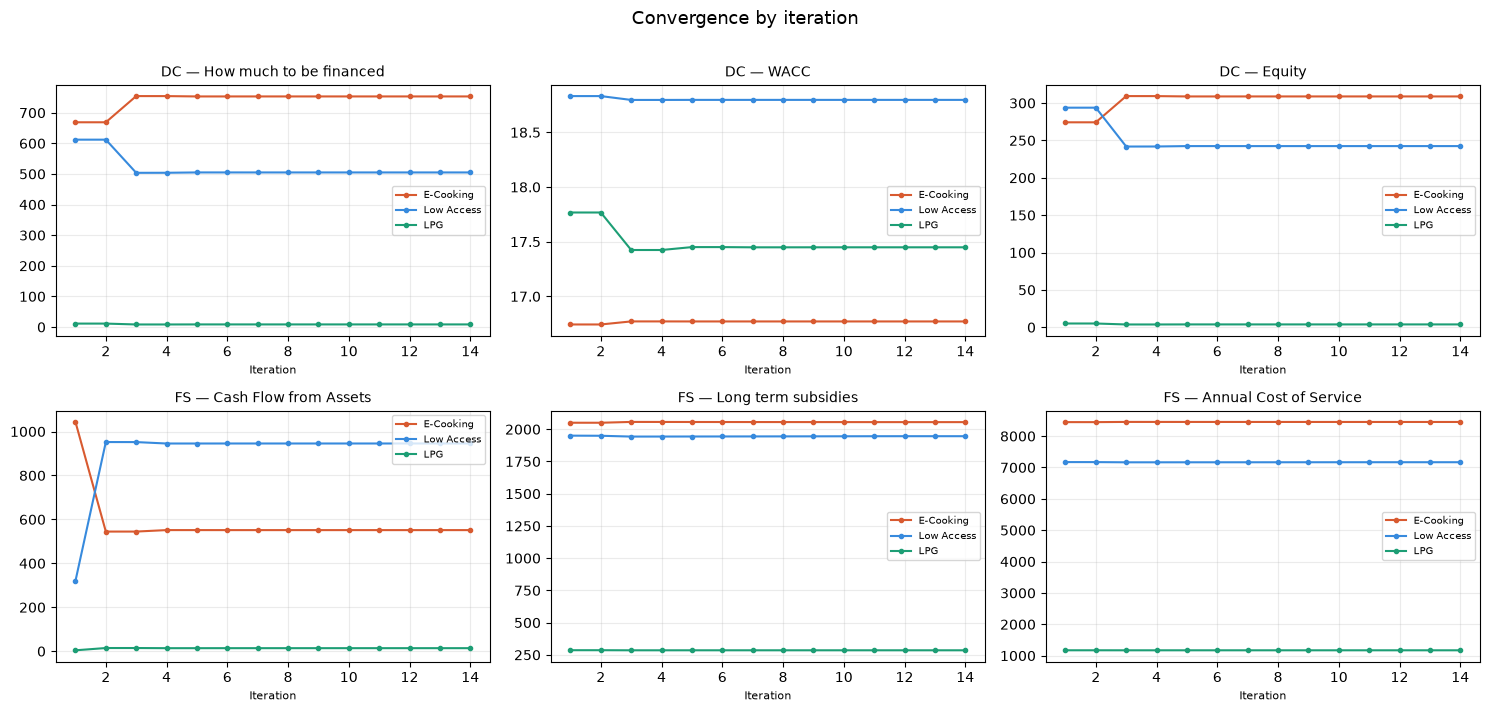

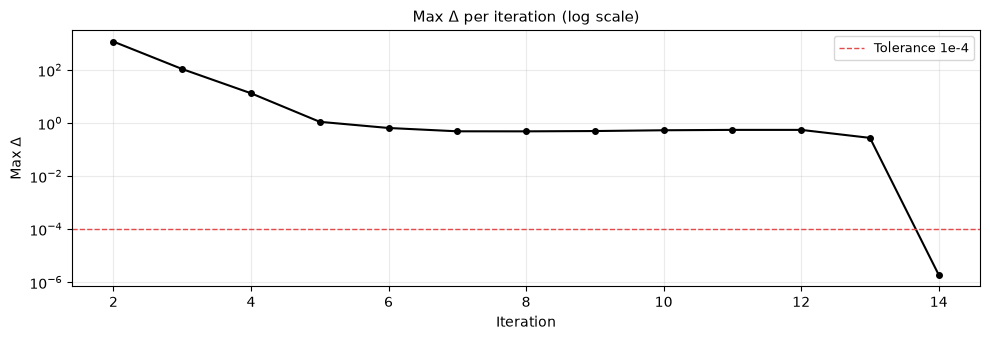

In [23]:
pio.plot_convergence(df_conv)

### Debt requirements

The platform calculates the annual debt needed to cover negative cash positions. 
Review below and optionally inject it back into the model before re-running.

In [24]:
print("=== REQUIRED DEBT PER TECHNOLOGY ===")
REQUIRED_DEBT = {}
for SHEET in pio.get_expanded_sheets():
    req = pio.read_required_debt(SHEET)
    REQUIRED_DEBT[SHEET] = req
    print(f"\n{SHEET}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  " + "".join(f"{round(v,1):>10}" for v in req))

=== REQUIRED DEBT PER TECHNOLOGY ===

Electricity & E-Cooking
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Electricity (Low access)
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

LPG
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [25]:
USE_REQUIRED_DEBT = False   # True = automatically inject platform-calculated debt
DEBT_OVERRIDE     = None   # Or: {'Electricity & E-Cooking': [0, 34, 96, 0, ...]}
MAX_DEBT_ITER     = 8 
DEBT_TOL          = 0.5

accumulated = {
    sheet: list(CAPITAL_STRUCTURE[sheet].get('DEBT_INCREASE', [0]*len(YEARS)))
    for sheet in pio.get_expanded_sheets()
}

if DEBT_OVERRIDE:
    for sheet, vals in DEBT_OVERRIDE.items():
        accumulated[sheet] = list(vals)

if USE_REQUIRED_DEBT or DEBT_OVERRIDE:
    print("=== DEBT CONVERGENCE LOOP ===")
    df_conv2 = None
    for debt_iter in range(MAX_DEBT_ITER):
        total_needed = 0
        for sheet in pio.get_expanded_sheets():
            req = pio.read_required_debt(sheet)
            total_needed += sum(req)
            for t, v in enumerate(req):
                if t < len(accumulated[sheet]):
                    accumulated[sheet][t] += v

        print(f"  Iter {debt_iter+1}: remaining debt needed = {total_needed:.2f} M$")

        if total_needed < DEBT_TOL:
            print(f"  Converged in {debt_iter+1} iteration(s).")
            break

        for sheet, vals in accumulated.items():
            pio.write_design_debt_list(sheet, vals)
            CAPITAL_STRUCTURE[sheet]['DEBT_INCREASE'] = vals

        df_conv2 = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
    else:
        print(f"  Warning: did not converge after {MAX_DEBT_ITER} iterations.")

    if df_conv2 is not None:
        display(df_conv2)

    print("\n=== FINAL INJECTED DEBT PER TECHNOLOGY ===")
    for sheet, vals in accumulated.items():
        print(f"\n{sheet}")
        print("  " + "".join(f"{y:>10}" for y in YEARS))
        print("  " + "".join(f"{round(v,1):>10}" for v in vals))
else:
    print("No debt injection applied.")

No debt injection applied.


## 6. Outputs

In [26]:
col_w = 10
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))
    check_vals = out.get('Check', [0]*len(YEARS))
    if any(abs(v) > 1 for v in check_vals):
        print(f"\n  ⚠  Balance sheet check FAILED: {[round(v,1) for v in check_vals]}")
    else:
        print(f"\n  ✓  Balance sheet OK")


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0         0      34.3      87.7      19.2     148.4     204.2     238.2     398.7     310.5     317.1     297.0
EBITDA                                  336.3     409.0     473.0     534.1     664.8     651.1     758.6     862.3     861.4    1028.0     826.0     882.2
Net Income                              285.5     342.5     389.0     439.3     505.8     523.6     614.6     696.2     731.1     817.1     593.6     622.5
Annual Cost of Service                  231.3     311.3     406.0     488.0     649.6     648.0     752.1     846.1     843.6    1030.6    1090.4    1154.5
Check                                

In [27]:
# === COMPARISON: PYOMO vs PLATFORM ===
col_w = 9

k1_annual = [cs['TARIFF_INCOME'][t] / cs['CAPEX_SCHEDULE'][t] 
             if cs['CAPEX_SCHEDULE'][t] != 0 else 0 
             for t in range(len(YEARS))]
print("  K1 anual: " + ''.join(f"{round(v,3):>9}" for v in k1_annual))

COMP_VARS = [
    ('Tariff Income',        'TARIFF_INCOME',        'Annual Cost of Service'),  # plataforma no tiene tariff directo, usamos ACoS como proxy
    ('Grants',               'GRANTS_PYOMO',         'GRANTS:- Realisation'),
    ('LT Subsidies',         'LT_SUBSIDY_SCHEDULE',  'Long term subsidies'),
    ('Revenues',             'REVENUES_PYOMO',        None),
    ('Costs',                'COSTS_PYOMO',           None),
    ('EBITDA',               'EBITDA_PYOMO',          'EBITDA'),
    ('ACoS',                 None,                    'Annual Cost of Service'),  # añadir ACoS plataforma
    ('Financial Expenses',   'FINANCIAL_EXP_PYOMO',   'Financial Expense'),
    ('CFA',                  'CFA_PYOMO',             'Cash Flow from Assets'),
    ('Debt Increase',        'DEBT_INCREASE',         'DEBT:+ Increase'),
    ('CAPEX (Pyomo)',        'CAPEX_SCHEDULE',         None),
    ('ACoS', 'ACOS_PYOMO', 'Annual Cost of Service'),
]

for sheet in pio.get_expanded_sheets():
    cs  = CAPITAL_STRUCTURE[sheet]
    out = pio.read_outputs(sheet)

    print(f"\n{'='*80}")
    print(f"  {sheet}  —  K1={cs['K1']:.3f}, K2={cs['K2']:.3f}")
    print(f"{'='*80}")

    # CAPEX real del technoeconomic (plataforma)
    if sheet == 'LPG':
        capex_real = TECHNO_LPG.get('CAPEX - Growth', [0]*len(YEARS))
    else:
        g  = TECHNO_ELEC[sheet].get('GRID',     {}).get('CAPEX - Growth', [0]*len(YEARS))
        og = TECHNO_ELEC[sheet].get('OFF-GRID', {}).get('CAPEX - Growth', [0]*len(YEARS))
        capex_real = [g[t]+og[t] for t in range(len(YEARS))]

    print("  CAPEX Platform: " + ''.join(f"{round(v,1):>9}" for v in capex_real))
    print("  CAPEX Pyomo:    " + ''.join(f"{round(v,1):>9}" for v in cs['CAPEX_SCHEDULE']))
    print()

    print(f"{'Variable':<25} {'Source':<10}" + ''.join(f"{y:>{col_w}}" for y in YEARS) + f"{'TOTAL':>{col_w}}")
    print('-'*80)

    for name, pyomo_key, platform_key in COMP_VARS:
        if pyomo_key and pyomo_key in cs:
            vals = cs[pyomo_key]
            tot  = round(sum(vals), 1)
            print(f"{name:<25} {'Pyomo':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if platform_key and platform_key in out:
            vals = out[platform_key]
            tot  = round(sum(vals), 1)
            print(f"{'':<25} {'Platform':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if pyomo_key or platform_key:
            print()

  K1 anual:     0.005    0.005    0.005    0.005    0.005    0.005    0.005    0.005    0.005    0.005    0.005    0.005

  Electricity & E-Cooking  —  K1=0.142, K2=0.483
  CAPEX Platform:     296.8    374.9    371.2    367.5    363.8    360.2    397.4    434.0    429.7    425.3    421.1    289.1
  CAPEX Pyomo:            0     44.4     36.9     57.5     95.9    160.6    268.9    450.2    753.7   1261.7    665.9    735.3

Variable                  Source         2023     2024     2025     2026     2027     2028     2029     2030     2031     2032     2033     2034    TOTAL
--------------------------------------------------------------------------------
Tariff Income             Pyomo             0      6.3      5.3      8.2     13.7     22.9     38.3     64.1    107.3    179.7     94.8    104.7    645.2
                          Platform      231.3    311.3    406.0    488.0    649.6    648.0    752.1    846.1    843.6   1030.6   1090.4   1154.5   8451.5

Grants                    Pyom

## 7. Summary metrics

In [28]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue

    lts      = out.get('Long term subsidies',  [0]*len(YEARS))
    equity   = out.get('Equity - EoP',         [0]*len(YEARS))
    debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
    grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next(
        (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
        None
    )
    _wb.close()

    total_lts    = round(sum(lts), 1)
    total_grants = round(sum(abs(v) for v in grants), 1)
    peak_equity  = round(max(equity), 1)
    peak_debt    = round(max(abs(v) for v in debt_eop), 1)

    print(f"\n{SHEET}")
    print(f"  WACC:               {wacc:.2f}%")
    print(f"  Total LTS:          {total_lts} M$")
    print(f"  Total grants:       {total_grants} M$")
    print(f"  Peak equity (EoP):  {peak_equity} M$")
    print(f"  Peak debt (EoP):    {peak_debt} M$")


Electricity & E-Cooking
  WACC:               16.77%
  Total LTS:          2055.4 M$
  Total grants:       2292.5 M$
  Peak equity (EoP):  5577.0 M$
  Peak debt (EoP):    12.3 M$

Electricity (Low access)
  WACC:               18.80%
  Total LTS:          1946.2 M$
  Total grants:       1704.1 M$
  Peak equity (EoP):  4191.7 M$
  Peak debt (EoP):    7.3 M$

LPG
  WACC:               17.45%
  Total LTS:          285.5 M$
  Total grants:       21.2 M$
  Peak equity (EoP):  39.0 M$
  Peak debt (EoP):    0.9 M$
